### ASSIGNMENT-6

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
df = sns.load_dataset('iris')

In [4]:
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [8]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [9]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

***List down the features and their types (e.g., numeric, nominal) available in the dataset.***

In [10]:
print("Feature Types")
print(df.info())
print("\nSummary of features and their types")

for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Feature: {column} | Type: Nominal (Categorical)")
    else:
        print(f"Feature: {column} | Type: Numeric (Continuous)")


Feature Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Summary of features and their types
Feature: sepal_length | Type: Numeric (Continuous)
Feature: sepal_width | Type: Numeric (Continuous)
Feature: petal_length | Type: Numeric (Continuous)
Feature: petal_width | Type: Numeric (Continuous)
Feature: species | Type: Nominal (Categorical)


***Create a histogram for each feature in the dataset to illustrate the feature distributions.***

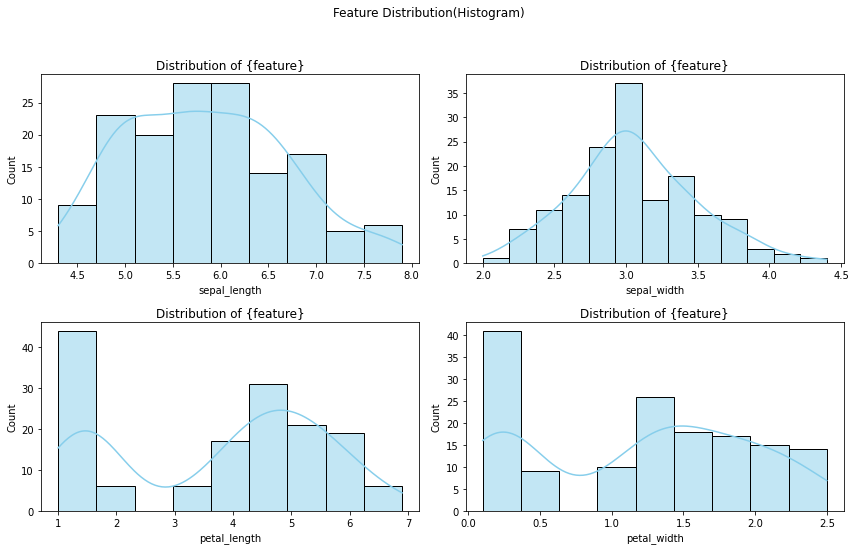

In [11]:
plt.figure(figsize = (12,8))
plt.suptitle("Feature Distribution(Histogram)")

numeric_features = df.columns[:-1]
for i,feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde = True, color = 'skyblue')
    plt.title("Distribution of {feature}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

***Create a box plot for each feature in the dataset.***

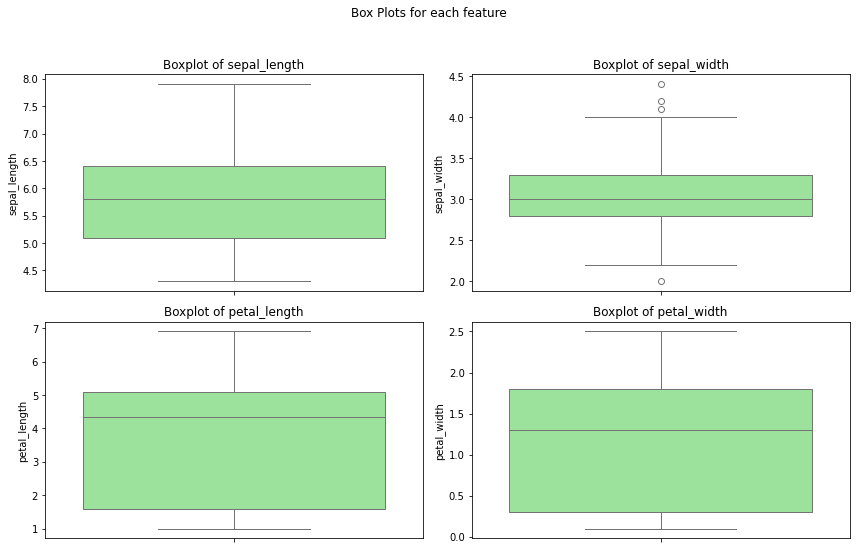

In [12]:
plt.figure(figsize=(12, 8))
plt.suptitle("Box Plots for each feature")

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

***Compare distributions and identify outliers***

In [13]:
#Statistical Comparison

print("Comparison according to the Mean Value of Species")
print(df.groupby('species').mean())

print("Comparison of all the statistical values")
comparison_table = df.groupby('species').describe().stack()

print(comparison_table)

Comparison according to the Mean Value of Species
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
Comparison of all the statistical values
                  sepal_length  sepal_width  petal_length  petal_width
species                                                               
setosa     count     50.000000    50.000000     50.000000    50.000000
           mean       5.006000     3.428000      1.462000     0.246000
           std        0.352490     0.379064      0.173664     0.105386
           min        4.300000     2.300000      1.000000     0.100000
           25%        4.800000     3.200000      1.400000     0.200000
           50%        5.000000     3.400000      1.500000     0.200000
           75%  

/tmp/ipykernel_5011/3498351924.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  comparison_table = df.groupby('species').describe().stack()


/tmp/ipykernel_5011/93105951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=feat, data=df, ax=axes[row, col], palette="muted")
/tmp/ipykernel_5011/93105951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=feat, data=df, ax=axes[row, col], palette="muted")
/tmp/ipykernel_5011/93105951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=feat, data=df, ax=axes[row, col], palette="muted")
/tmp/ipykernel_5011/93105951.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is 

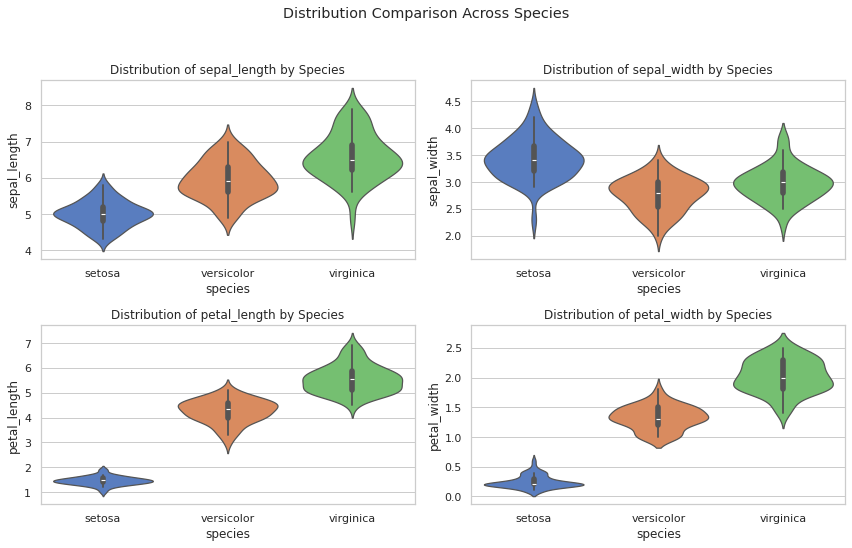

In [14]:
#Visual Comparison
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12 , 8))
fig.suptitle("Distribution Comparison Across Species")

for i, feat in enumerate(numeric_features):
    row, col = i // 2, i % 2
    sns.violinplot(x='species', y=feat, data=df, ax=axes[row, col], palette="muted")
    axes[row, col].set_title(f'Distribution of {feat} by Species')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [15]:
#Identifying outliers using IQR Method

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    print(f"\nDetected {len(outliers)} outliers in {feature}")
    if len(outliers) > 0:
        print(outliers)


Detected 0 outliers in sepal_length

Detected 4 outliers in sepal_width
    sepal_length  sepal_width  petal_length  petal_width     species
15           5.7          4.4           1.5          0.4      setosa
32           5.2          4.1           1.5          0.1      setosa
33           5.5          4.2           1.4          0.2      setosa
60           5.0          2.0           3.5          1.0  versicolor

Detected 0 outliers in petal_length

Detected 0 outliers in petal_width
